In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from typing import List

pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 1000)

In [9]:
data25 = pd.read_csv('data/2025.csv')
data24 = pd.read_csv('data/2024.csv')
data23 = pd.read_csv('data/2023.csv')
data22 = pd.read_csv('data/2022.csv')
data21 = pd.read_csv('data/2021.csv')
data20 = pd.read_csv('data/2020.csv')
data19 = pd.read_csv('data/2019.csv')
data18 = pd.read_csv('data/2018.csv')
data17 = pd.read_csv('data/2017.csv')
data16 = pd.read_csv('data/2016.csv')


In [10]:
import sys
from pathlib import Path

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / 'src').exists():
    project_root = project_root.parent
if (project_root / 'src').exists():
    sys.path.insert(0, str(project_root))

from model_shared.db import get_read_cursor

swing_code = ['foul_bunt', 'foul', 'hit_into_play', 'swinging_strike', 'foul_tip', 'swinging_strike_blocked', 'missed_bunt', 'bunt_foul_tip']

def categorize_pitch(row: pd.Series) -> str:
    description = row['description']
    
    if description in swing_code:
        return 'swing'
    return 'no_swing'
  

def get_historical_data(year: int=2024) -> pd.DataFrame:
    query = """
        SELECT
            bb.player_id,
            bb.position,
            pd.whiff_percentage,
            pd.chase_percentage,
            pd.zone_percentage,
            pd.zone_swing_percentage,
            pd.zone_contact_percentage,
            pd.first_pitch_swing_percentage,
            pd.meatball_swing_percentage,
            pt.pitch_type,
            pt.pitch_count,
            pt.strikeouts,
            pt.batted_ball_events,
            pt.putaway_percentage,
            pt.whiff_percentage AS pitch_whiff_percentage
        FROM batted_ball_profile bb 
        JOIN plate_discipline pd
            ON bb.player_id = pd.player_id
            AND bb.position = pd.position
            AND bb.year = pd.year
        JOIN pitch_tracking pt
            ON bb.player_id = pt.player_id
            AND bb.position = pt.position
            AND bb.year = pt.year
        WHERE bb.year = %s;
    """

    with get_read_cursor() as cursor:
        df = pd.read_sql(query, cursor.connection, params=(year,))
    return df

def df_process(df) -> pd.DataFrame:
    df = df.sort_values(['game_date', 'game_pk', 'at_bat_number', 'pitch_number'])

    df['outcome'] = df.apply(categorize_pitch, axis=1)

    df['runner_on_1b'] = df['on_1b'].notna().astype(int)
    df['runner_on_2b'] = df['on_2b'].notna().astype(int)
    df['runner_on_3b'] = df['on_3b'].notna().astype(int)

    df['prev_pitch_type'] = df.groupby(['game_pk', 'at_bat_number'])['pitch_type'].shift(1)
    df['prev_pitch_type'] = df['prev_pitch_type'].fillna('NONE')

    df['prev_zone'] = df.groupby(['game_pk', 'at_bat_number'])['zone'].shift(1)
    df['prev_zone'] = df['prev_zone'].fillna(0)

    return df

In [11]:
def get_features(out_data: pd.DataFrame, features: List[str]) -> pd.DataFrame:
    final_features = list(features)

    model_data = out_data[final_features]

    cat_cols = ['pitch_type', 'stand', 'p_throws', 'inning_topbot', 'prev_pitch_type', 'prev_swing', 'zone_pitch']

    existing_cat_cols = [c for c in cat_cols if c in model_data.columns]
    model_data = pd.get_dummies(model_data, columns=existing_cat_cols, drop_first=True)
    return model_data

def get_zone_metrics(year: int=2024) -> pd.DataFrame:
    query = """
        SELECT
            player_id,
            position,
            metric,
            zone1,
            zone2,
            zone3,
            zone4,
            zone5,
            zone6,
            zone7,
            zone8,
            zone9,
            zone11,
            zone12,
            zone13,
            zone14
        FROM zone_metrics
        WHERE year = %s
            AND metric IN ('strikeout_percentage', 'whiff_percentage', 'walk_percentage', 'swing_percentage')
    """
    with get_read_cursor() as cursor:
        df = pd.read_sql(query, cursor.connection, params=(year,))

    df_long = pd.melt(
        df, 
        id_vars=['player_id', 'position', 'metric'], 
        var_name='zone', 
        value_name='metric_value'
    )
    df_long['zone'] = df_long['zone'].str.replace('zone', '').astype(int)
    
    df_final = df_long.pivot_table(
        index=['player_id', 'position', 'zone'], 
        columns='metric', 
        values='metric_value'
    ).reset_index()
    
    return df_final


features = [
    'p_throws', 
    'stand', 
    'balls', 
    'pitch_type',
    'zone',
    'strikes', 
    'runner_on_1b',
    'runner_on_2b', 
    'runner_on_3b', 
    'outs_when_up', 
    'inning',
    'bat_score',
    'fld_score',
    'inning_topbot',
    'sz_top',
    'sz_bot',
    'description',
    'prev_pitch_type',
    'prev_zone',
    'batter_prev_whiff_rate', 
    'batter_prev_chase_rate',
    'batter_prev_looking_strike_rate',
    'batter_prev_zone_contact_rate',
    'pitcher_prev_whiff_rate', 
    'game_date',
    'game_pk',
    'pitch_number',
    'outcome',
    'pitcher_pitch_putaway_rate',
    'batter_pitch_putaway_rate',
    'pitcher_pitch_whiff_rate',
    'batter_pitch_whiff_rate',
    'batter_zone_strikeout_percentage',
    'pitcher_zone_strikeout_percentage',
    'batter_zone_whiff_percentage',
    'pitcher_zone_whiff_percentage',
    'batter_zone_walk_percentage',
    'pitcher_zone_walk_percentage',
    'batter_zone_swing_percentage',
    'pitcher_zone_swing_percentage',
    'pitcher_prev_first_pitch_swing_rate',
    'batter_prev_first_pitch_swing_rate',
    'pitcher_prev_meatball_swing_rate',
    'batter_prev_meatball_swing_rate'
]


def build_season_features(current_pitch_data: pd.DataFrame, historical_year: int) -> pd.DataFrame:
    historical_df = get_historical_data(historical_year)
    zone_metrics_df = get_zone_metrics(historical_year)

    prev_cols = [
        'player_id', 'position', 'whiff_percentage', 'chase_percentage', 'zone_contact_percentage',
        'zone_percentage', 'zone_swing_percentage', 'first_pitch_swing_percentage', 'meatball_swing_percentage'
    ]

    batter_baselines = historical_df[historical_df['position'] == 'B'][prev_cols].drop_duplicates().add_prefix('batter_prev_')
    pitcher_baselines = historical_df[historical_df['position'] == 'P'][prev_cols].drop_duplicates().add_prefix('pitcher_prev_')

    pitch_data = current_pitch_data.merge(batter_baselines, left_on='batter', right_on='batter_prev_player_id', how='left')
    pitch_data = pitch_data.merge(pitcher_baselines, left_on='pitcher', right_on='pitcher_prev_player_id', how='left')

    pt_cols = [
        'player_id', 'position', 'pitch_type', 'pitch_count', 'strikeouts', 'batted_ball_events',
        'putaway_percentage', 'pitch_whiff_percentage'
    ]

    batter_pt = historical_df[historical_df['position'] == 'B'][pt_cols].drop_duplicates().add_prefix('batter_pitch_')
    pitcher_pt = historical_df[historical_df['position'] == 'P'][pt_cols].drop_duplicates().add_prefix('pitcher_pitch_')

    pitch_data = pitch_data.merge(batter_pt, left_on=['batter', 'pitch_type'], right_on=['batter_pitch_player_id', 'batter_pitch_pitch_type'], how='left')
    pitch_data = pitch_data.merge(pitcher_pt, left_on=['pitcher', 'pitch_type'], right_on=['pitcher_pitch_player_id', 'pitcher_pitch_pitch_type'], how='left')

    batter_zone = zone_metrics_df[zone_metrics_df['position'] == 'B'].drop_duplicates().add_prefix('batter_zone_')
    pitcher_zone = zone_metrics_df[zone_metrics_df['position'] == 'P'].drop_duplicates().add_prefix('pitcher_zone_')

    pitch_data = pitch_data.merge(batter_zone, left_on=['batter', 'zone'], right_on=['batter_zone_player_id', 'batter_zone_zone'], how='left')
    pitch_data = pitch_data.merge(pitcher_zone, left_on=['pitcher', 'zone'], right_on=['pitcher_zone_player_id', 'pitcher_zone_zone'], how='left')

    pitch_data = pitch_data.rename(columns={
        'batter_prev_whiff_percentage': 'batter_prev_whiff_rate',
        'batter_prev_chase_percentage': 'batter_prev_chase_rate',
        'batter_prev_zone_contact_percentage': 'batter_prev_zone_contact_rate',
        'batter_pitch_putaway_percentage': 'batter_pitch_putaway_rate',
        'batter_pitch_pitch_whiff_percentage': 'batter_pitch_whiff_rate',
        'batter_prev_first_pitch_swing_percentage': 'batter_prev_first_pitch_swing_rate',
        'batter_prev_meatball_swing_percentage': 'batter_prev_meatball_swing_rate',
        'pitcher_prev_whiff_percentage': 'pitcher_prev_whiff_rate',
        'pitcher_prev_chase_percentage': 'pitcher_prev_chase_rate',
        'pitcher_pitch_putaway_percentage': 'pitcher_pitch_putaway_rate',
        'pitcher_pitch_pitch_whiff_percentage': 'pitcher_pitch_whiff_rate',
        'pitcher_prev_first_pitch_swing_percentage': 'pitcher_prev_first_pitch_swing_rate',
        'pitcher_prev_meatball_swing_percentage': 'pitcher_prev_meatball_swing_rate',
    })

    pitch_data['batter_prev_looking_strike_rate'] = pitch_data['batter_prev_zone_percentage'] * (1 - pitch_data['batter_prev_zone_swing_percentage'] / 100.0)

    pitch_data = pitch_data.drop(columns=[
        'batter_prev_zone_swing_percentage',
        'batter_prev_zone_percentage', 
        'pitcher_prev_zone_swing_percentage',
        'pitcher_prev_zone_percentage',
        'pitcher_prev_zone_contact_percentage',
    ])

    sql_pct_cols = [
        'batter_prev_whiff_rate', 'batter_prev_chase_rate', 'batter_prev_looking_strike_rate',
        'batter_prev_zone_contact_rate', 'batter_pitch_putaway_rate',
        'batter_pitch_whiff_rate', 'pitcher_prev_whiff_rate', 'pitcher_prev_chase_rate', 
        'pitcher_pitch_putaway_rate', 'pitcher_pitch_whiff_rate',
        'batter_prev_first_pitch_swing_rate', 'pitcher_prev_first_pitch_swing_rate',
        'batter_prev_meatball_swing_rate', 'pitcher_prev_meatball_swing_rate'
    ]

    for col in sql_pct_cols:
        if col in pitch_data.columns:
            pitch_data[col] = pitch_data[col] / 100.0
            
    return pitch_data


df_25 = df_process(data25)
df_24 = df_process(data24)
df_23 = df_process(data23)
df_22 = df_process(data22)
df_21 = df_process(data21)
df_20 = df_process(data20)
df_19 = df_process(data19)
df_18 = df_process(data18)
df_17 = df_process(data17)
df_16 = df_process(data16)
pitch_data = []

for df, year in [
    (df_16, 2015),
    (df_17, 2016),
    (df_18, 2017),
    (df_19, 2018),
    (df_20, 2019),
    (df_21, 2020),
    (df_22, 2021),
    (df_23, 2022),
    (df_24, 2023),
    (df_25, 2024),
]:
    print(f"Building {year+1} features...")
    tmp = build_season_features(df, historical_year=year)
    pitch_data.append(tmp)

pitch_data = pd.concat(pitch_data, ignore_index=True)

print("Total combined rows:", len(pitch_data))

model_data = get_features(pitch_data, features)


Building 2016 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_27236\2954246426.py:53: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_27236\3227329365.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Building 2017 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_27236\2954246426.py:53: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_27236\3227329365.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Building 2018 features...


...

Building 2024 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_27236\2954246426.py:53: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_27236\3227329365.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Building 2025 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_27236\2954246426.py:53: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_27236\3227329365.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Total combined rows: 6829672


[0]	validation_0-auc:0.75899
[100]	validation_0-auc:0.80147
[200]	validation_0-auc:0.80813
[300]	validation_0-auc:0.81022
[400]	validation_0-auc:0.81224
[500]	validation_0-auc:0.81341
[600]	validation_0-auc:0.81404
[700]	validation_0-auc:0.81432
[748]	validation_0-auc:0.81430
strikes                                0.143282
prev_pitch_type_NONE                   0.124059
batter_zone_swing_percentage           0.111272
two_strikes                            0.092458
zone                                   0.080241
balls                                  0.040239
pitcher_zone_swing_percentage          0.033580
prev_zone                              0.032696
pitch_type_CU                          0.022940
pitch_type_FF                          0.022780
sz_bot                                 0.021708
sz_top                                 0.016931
runner_on_3b                           0.015048
runner_on_1b                           0.014788
pitch_type_CH                          0.014610
ful

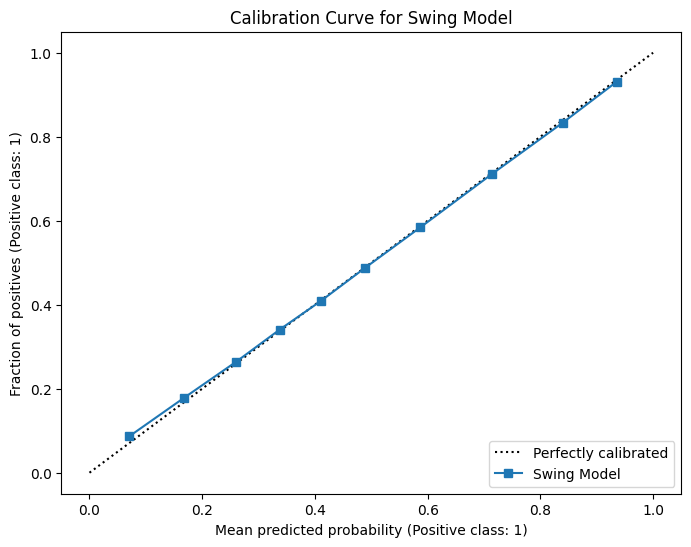

Probability metrics:
Log Loss: 0.52881
Brier Score: 0.17714
Distribution Check:
Real Swing Rate: 0.4790
Predicted Avg Prob: 0.4775
Simulated Swing Rate: 0.4772


In [12]:
from matplotlib import pyplot as plt
from sklearn.frozen import FrozenEstimator
import xgboost as xgb
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import log_loss, brier_score_loss
import joblib

model_data['target'] = (model_data['outcome'] == 'swing').astype(int)

model_data['two_strikes'] = (model_data['strikes'] == 2).astype(int)
model_data['full_count'] = ((model_data['balls'] == 3) & (model_data['strikes'] == 2)).astype(int)
model_data['is_platoon'] = model_data['p_throws_R'] != model_data['stand_R']


X_features = [col for col in model_data.columns if col not in ['target', 'outcome', 'game_date', 'game_pk', 'pitch_number', 'description']]
model_data = model_data.sort_values(['game_date', 'game_pk', 'pitch_number'])

length = len(model_data)

train_end = int(length * 0.7)
val_end = int(length * 0.85)

train_data = model_data.iloc[:train_end]
val_data = model_data.iloc[train_end:val_end]
test_data = model_data.iloc[val_end:]

X_train = train_data[X_features]
y_train = train_data['target']

X_val = val_data[X_features]
y_val= val_data['target']

X_test = test_data[X_features]
y_test = test_data['target']


xgb_swing = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=1500,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=42
)

xgb_swing.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

calibrated_swing = CalibratedClassifierCV(FrozenEstimator(xgb_swing), method='isotonic')
calibrated_swing.fit(X_val, y_val)

y_proba = calibrated_swing.predict_proba(X_test)[:, 1]

joblib.dump({
    'model': calibrated_swing,
    'features': X_features
}, 'models/swing_model_v1.pkl')


importance = pd.Series(
    xgb_swing.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
print(importance)



fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_test == 1).astype(int),
    y_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='Swing Model'
)
plt.title('Calibration Curve for Swing Model')
plt.show()

ll = log_loss(y_test, y_proba)
brier_score = brier_score_loss(y_test, y_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_swings = (np.random.rand(len(y_proba)) < y_proba).astype(int)

real_rate = y_test.mean()
pred_rate = y_proba.mean()
sim_rate = simulated_swings.mean()

print("Distribution Check:")
print(f"Real Swing Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated Swing Rate: {sim_rate:.4f}")

[0]	validation_0-aucpr:0.91611
[100]	validation_0-aucpr:0.92522
[200]	validation_0-aucpr:0.92598
[300]	validation_0-aucpr:0.92622
[361]	validation_0-aucpr:0.92620
zone                                 0.565036
batter_zone_walk_percentage          0.104501
strikes                              0.049269
two_strikes                          0.042578
pitcher_zone_walk_percentage         0.032086
stand_R                              0.013825
pitch_type_FF                        0.013417
balls                                0.012121
pitch_type_CH                        0.010016
p_throws_R                           0.009321
pitch_type_SI                        0.008760
sz_top                               0.008595
pitch_type_IN                        0.008489
sz_bot                               0.007410
pitch_type_FS                        0.006199
prev_pitch_type_IN                   0.006067
runner_on_3b                         0.005691
runner_on_2b                         0.005631
full_coun

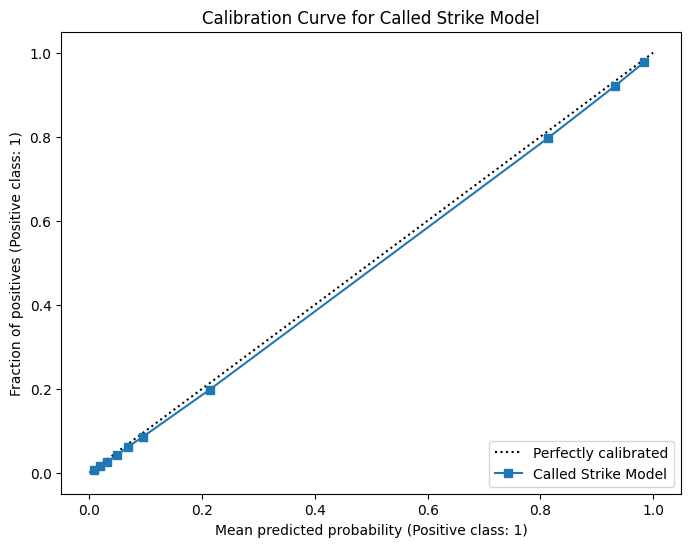

Probability metrics:
Log Loss: 0.22077
Brier Score: 0.06023
Distribution Check:
Real Called Strike Rate: 0.3118
Predicted Avg Prob: 0.3201
Simulated Called Strike Rate: 0.3204


In [13]:
if 'target' not in model_data.columns:
    model_data['target'] = (model_data['outcome'] == 'swing').astype(int)


take_data = model_data[model_data['target'] == 0].copy()
take_data['called_strike'] = (take_data['description'] == 'called_strike').astype(int)

X_take_features = [col for col in take_data.columns if col not in [
    'target', 'outcome', 'game_date', 'game_pk', 'pitch_number', 'called_strike', 'description',
    'batter_prev_whiff_rate', 'pitcher_prev_whiff_rate', 'batter_pitch_whiff_rate', 'pitcher_pitch_whiff_rate',
    'batter_prev_chase_rate', 'pitcher_prev_chase_rate', 'batter_zone_swing_percentage', 'pitcher_zone_swing_percentage',
    'batter_pitch_putaway_rate', 'pitcher_pitch_putaway_rate', 'batter_prev_meatball_swing_rate', 'pitcher_prev_meatball_swing_rate',
    'batter_prev_first_pitch_swing_rate', 'pitcher_prev_first_pitch_swing_rate', 'batter_prev_zone_contact_rate', 'pitcher_prev_zone_contact_rate'
]]

take_data = take_data.sort_values(['game_date', 'game_pk', 'pitch_number'])

length = len(take_data)

train_end = int(length * 0.7)
val_end = int(length * 0.85)

train_data = take_data.iloc[:train_end]
val_data = take_data.iloc[train_end:val_end]
test_data = take_data.iloc[val_end:]

X_take_train = train_data[X_take_features]
y_take_train = train_data['called_strike']

X_take_val = val_data[X_take_features]
y_take_val = val_data['called_strike']

X_take_test = test_data[X_take_features]
y_take_test = test_data['called_strike']

xgb_take = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=1500,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42
)

xgb_take.fit(X_take_train, y_take_train, eval_set=[(X_take_val, y_take_val)], verbose=100)

calibrated_take= CalibratedClassifierCV(FrozenEstimator(xgb_take), method='isotonic')
calibrated_take.fit(X_take_val, y_take_val)

y_take_proba = calibrated_take.predict_proba(X_take_test)[:, 1]

joblib.dump({
    "model": calibrated_take,
    "features": X_take_features
}, "models/called_strike_model_v1.pkl")

importance = pd.Series(
    xgb_take.feature_importances_,
    index=X_take_train.columns
).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_take_test == 1).astype(int),
    y_take_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='Called Strike Model'
)
plt.title('Calibration Curve for Called Strike Model')
plt.show()

ll = log_loss(y_take_test, y_take_proba)
brier_score = brier_score_loss(y_take_test, y_take_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_swings = (np.random.rand(len(y_take_proba)) < y_take_proba).astype(int)

real_rate = y_take_test.mean()
pred_rate = y_take_proba.mean()
sim_rate = simulated_swings.mean()

print("Distribution Check:")
print(f"Real Called Strike Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated Called Strike Rate: {sim_rate:.4f}")

zone                            0.565036
batter_zone_walk_percentage     0.104501
strikes                         0.049269
two_strikes                     0.042578
pitcher_zone_walk_percentage    0.032086
stand_R                         0.013825
pitch_type_FF                   0.013417
balls                           0.012121
pitch_type_CH                   0.010016
p_throws_R                      0.009321
dtype: float32
              precision    recall  f1-score   support

     P(Ball)       0.92      0.96      0.94    367317
   P(Strike)       0.90      0.81      0.85    166375

    accuracy                           0.91    533692
   macro avg       0.91      0.89      0.90    533692
weighted avg       0.91      0.91      0.91    533692

[[352816  14501]
 [ 31628 134747]]


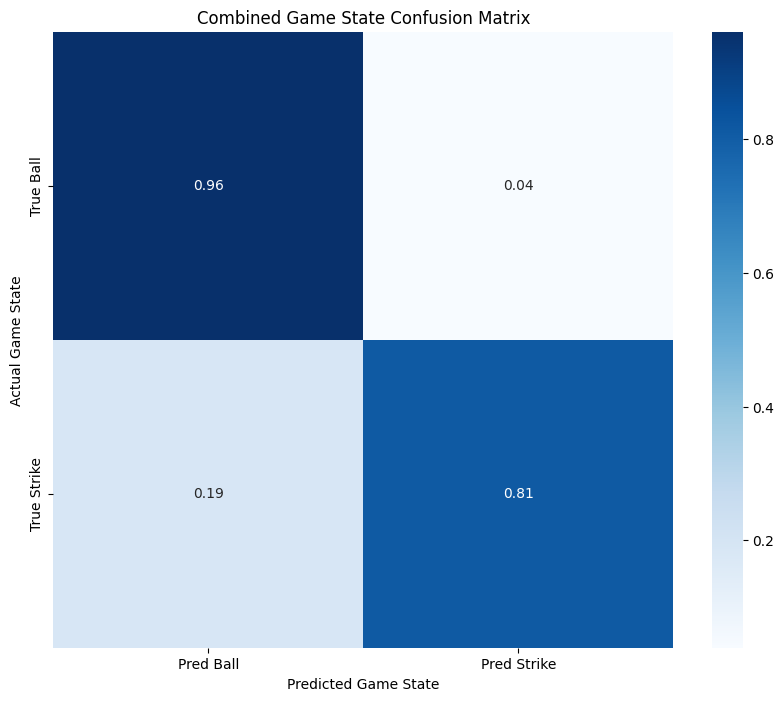

In [14]:
def get_pitch_probabilities(X_full: pd.DataFrame, calibrated_swing: CalibratedClassifierCV, calibrated_take: CalibratedClassifierCV) -> pd.DataFrame:
    swing_features = calibrated_swing.estimator.get_booster().feature_names
    take_features = calibrated_take.estimator.get_booster().feature_names

    p_swing_raw = xgb_swing.predict_proba(X_full[swing_features])[:, 1]

    # model slightly overestimates swings, adjusting down a bit
    p_swing = p_swing_raw * 0.97

    p_take = 1 - p_swing

    p_strike_given_take = xgb_take.predict_proba(X_full[take_features])[:, 1]
    p_ball_given_take = 1 - p_strike_given_take

    p_called_strike = p_take * p_strike_given_take
    p_ball = p_take * p_ball_given_take

    p_strike = p_swing + p_called_strike

    total = p_strike + p_ball
    p_strike /= total
    p_ball /= total

    probs = pd.DataFrame({
        'P(Strike)': p_strike,
        'P(Ball)': p_ball,
    }, index=X_full.index)

    return probs

prob_df = get_pitch_probabilities(X_test, calibrated_swing, calibrated_take)


def get_actual_binary(row: pd.Series) -> str:
    if row['outcome'] == 'swing' or row['description'] == 'called_strike':
        return 'P(Strike)'
    return 'P(Ball)'

y_true_combined = test_data.apply(get_actual_binary, axis=1)

common_index = y_true_combined.index.intersection(prob_df.index)
y_true_aligned = y_true_combined.loc[common_index]

# model is pretty confident at extreme strike probabilities, use higher threshold when classifying strikes
y_pred_aligned = np.where(prob_df.loc[common_index, 'P(Strike)'] >= 0.85, 'P(Strike)', 'P(Ball)')

importance_take = pd.Series(
    calibrated_take.estimator.feature_importances_,
    index=X_take_train.columns
).sort_values(ascending=False)
print(importance_take.head(10))

print(classification_report(y_true_aligned, y_pred_aligned))

cm = confusion_matrix(y_true_aligned, y_pred_aligned, labels=['P(Ball)', 'P(Strike)'])
print(cm)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    fmt=".2f",
    annot=True,
    xticklabels=['Pred Ball', 'Pred Strike'],
    yticklabels=['True Ball', 'True Strike']
)
plt.xlabel("Predicted Game State")
plt.ylabel("Actual Game State")
plt.title(f"Combined Game State Confusion Matrix")
plt.show()

